# E-commerce Sales & Customer Analytics

## Project Objective

The goal of this project is to analyze more than one million e-commerce
transactions and identify the main drivers of revenue and customer value.

The analysis focuses on four business questions:

1. How is revenue changing over time and are there seasonal patterns?
2. Which geographic markets and products generate the most revenue?
3. Who are the retailer's most valuable customers?
4. Which customer and market segments represent the strongest growth opportunities?

The final output includes an Excel executive dashboard and data-driven
business recommendations.

In [3]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Data Loading

The original Excel workbook contains two worksheets representing
two consecutive years of transactional data. Both datasets will be
combined into a single analytical dataset.

In [4]:
file_path = "../data/raw/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [5]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print("2009-2010:", df_2009_2010.shape)
print("2010-2011:", df_2010_2011.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [6]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## UNDERSTANDING DATA

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [8]:
df = df.rename(columns={
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID"
})

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"1,067,371.00",1067371,"1,067,371.00","824,364.00"
mean,9.94,2011-01-02 21:13:55.394029,4.65,"15,324.64"
min,"-80,995.00",2009-12-01 07:45:00,"-53,594.36","12,346.00"
25%,1.00,2010-07-09 09:46:00,1.25,"13,975.00"
50%,3.00,2010-12-07 15:28:00,2.10,"15,255.00"
75%,10.00,2011-07-22 10:23:00,4.15,"16,797.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,172.71,NaN,123.55,"1,697.46"


i see her negative values, but maybe it just cancelled transactions

In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

CustomerID     243007
Description      4382
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [11]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

CustomerID    22.77
Description    0.41
InvoiceNo      0.00
StockCode      0.00
Quantity       0.00
InvoiceDate    0.00
UnitPrice      0.00
Country        0.00
dtype: float64

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 34335


In [13]:
print(
    "Negative quantity:",
    (df["Quantity"] < 0).sum()
)

print(
    "Zero or negative prices:",
    (df["UnitPrice"] <= 0).sum()
)

Negative quantity: 22950
Zero or negative prices: 6207


In [14]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["IsCancelled"] = (
    df["InvoiceNo"]
    .str
    .startswith("C")
)

df["IsCancelled"].value_counts()

IsCancelled
False    1047877
True       19494
Name: count, dtype: int64

In [15]:
total_invoices = df["InvoiceNo"].nunique()

cancelled_invoices = df.loc[
    df["IsCancelled"],
    "InvoiceNo"
].nunique()

cancellation_rate = (
    cancelled_invoices / total_invoices * 100
)

print("Total invoices:", total_invoices)
print("Cancelled invoices:", cancelled_invoices)
print(f"Cancellation rate: {cancellation_rate:.2f}%")

Total invoices: 53628
Cancelled invoices: 8292
Cancellation rate: 15.46%


## CLEANING

For sales/revenue analysis, we need completed transactions.

Therefore, we remove:

- cancelled invoices;
- Quantity <= 0;
- UnitPrice <= 0;
- missing Description.

In [16]:
sales_df = df[
    (~df["IsCancelled"]) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (df["Description"].notna())
].copy()

print("Original rows:", len(df))
print("Clean sales rows:", len(sales_df))

Original rows: 1067371
Clean sales rows: 1041670


In [17]:
sales_df = sales_df.drop_duplicates()

print("Rows after removing duplicates:", len(sales_df))

Rows after removing duplicates: 1007913


In [18]:
sales_df["InvoiceDate"] = pd.to_datetime(
    sales_df["InvoiceDate"]
)

print(sales_df["InvoiceDate"].min())
print(sales_df["InvoiceDate"].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


## FEATURE ENGINEERING

In [19]:
#Revenue
sales_df["Revenue"] = (
    sales_df["Quantity"] *
    sales_df["UnitPrice"]
)

sales_df[
    ["Quantity", "UnitPrice", "Revenue"]
].head()

,Quantity,UnitPrice,Revenue
0,12,6.95,83.40
1,12,6.75,81.00
2,12,6.75,81.00
3,48,2.10,100.80
4,24,1.25,30.00


In [20]:
#time variables
sales_df["Year"] = sales_df["InvoiceDate"].dt.year

sales_df["Month"] = sales_df["InvoiceDate"].dt.month

sales_df["MonthName"] = sales_df["InvoiceDate"].dt.month_name()

sales_df["YearMonth"] = (
    sales_df["InvoiceDate"]
    .dt
    .to_period("M")
    .astype(str)
)

sales_df["DayOfWeek"] = (
    sales_df["InvoiceDate"]
    .dt
    .day_name()
)

sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

## EXECUTIVE KPIs

The first step is to establish the overall scale and performance of
the business using a small set of executive-level metrics.

In [21]:
total_revenue = sales_df["Revenue"].sum()

total_orders = sales_df["InvoiceNo"].nunique()

total_customers = sales_df["CustomerID"].nunique()

total_products = sales_df["StockCode"].nunique()

countries = sales_df["Country"].nunique()

average_order_value = (
    sales_df.groupby("InvoiceNo")["Revenue"].sum().mean()
)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Customers: {total_customers:,}")
print(f"Products: {total_products:,}")
print(f"Countries: {countries}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £20,476,260.45
Total Orders: 40,077
Customers: 5,878
Products: 4,917
Countries: 43
Average Order Value: £510.92


## REVENUE TREND

When does the business generate its revenue?

In [22]:
monthly_revenue = (
    sales_df
    .groupby("YearMonth", as_index=False)["Revenue"]
    .sum()
)

monthly_revenue

,YearMonth,Revenue
0,2009-12,"822,483.95"
1,2010-01,"651,155.11"
2,2010-02,"551,504.73"
3,2010-03,"830,915.26"
4,2010-04,"678,875.25"
5,2010-05,"657,705.50"
6,2010-06,"749,537.31"
7,2010-07,"648,810.27"
8,2010-08,"695,251.91"
9,2010-09,"921,696.99"


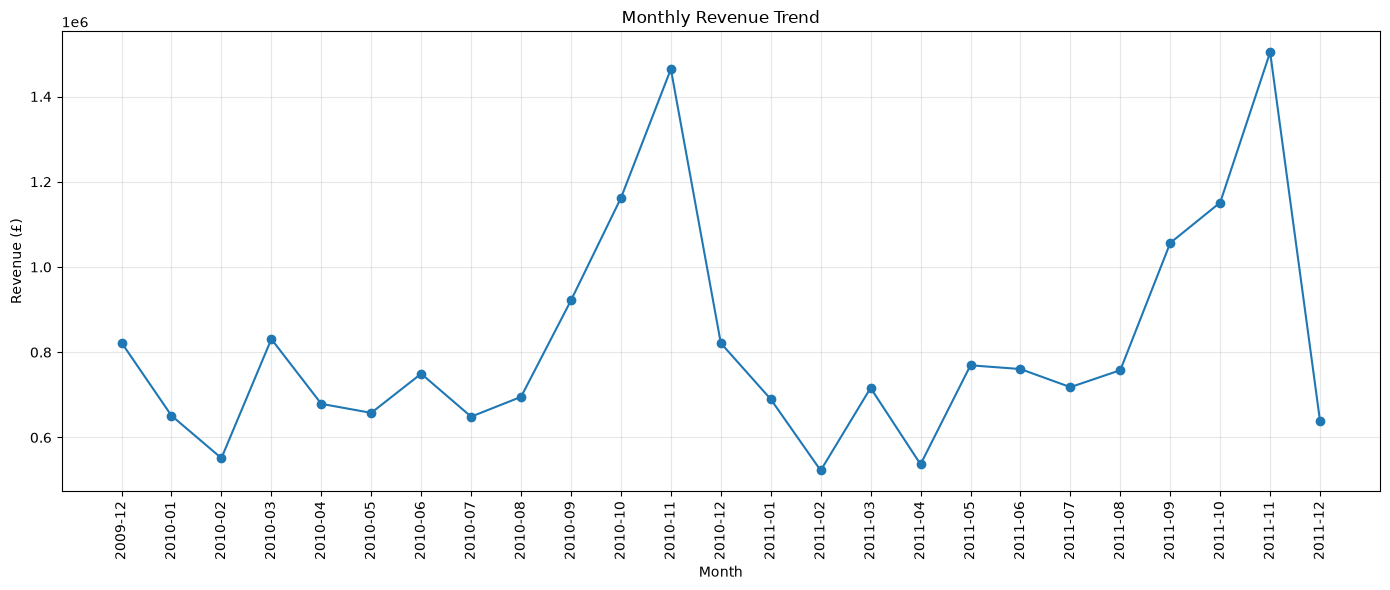

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
revenue_by_month = (
    sales_df
    .groupby("Month", as_index=False)["Revenue"]
    .sum()
)

revenue_by_month

,Month,Revenue
0,1,"1,340,966.72"
1,2,"1,074,050.29"
2,3,"1,547,130.52"
3,4,"1,215,843.74"
4,5,"1,427,002.11"
5,6,"1,510,084.32"
6,7,"1,366,886.39"
7,8,"1,453,093.29"
8,9,"1,978,132.18"
9,10,"2,313,165.95"


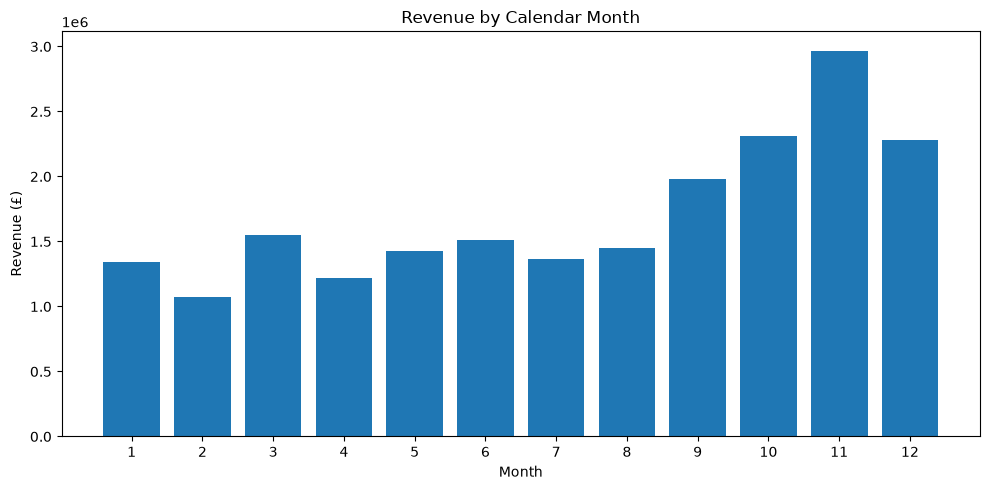

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    revenue_by_month["Month"],
    revenue_by_month["Revenue"]
)

plt.title("Revenue by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Q4 VS REST OF YEAR

In [26]:
sales_df["Quarter"] = (
    sales_df["InvoiceDate"]
    .dt
    .quarter
)

quarter_revenue = (
    sales_df
    .groupby("Quarter")["Revenue"]
    .sum()
)

quarter_revenue

Quarter
1   3,962,147.53
2   4,152,930.17
3   4,798,111.86
4   7,563,070.88
Name: Revenue, dtype: float64

In [27]:
q4_share = (
    quarter_revenue.loc[4] /
    quarter_revenue.sum() *
    100
)

print(
    f"Q4 generates {q4_share:.1f}% of total revenue."
)

Q4 generates 36.9% of total revenue.


## COUNTRY ANALYSIS

Which geographic markets generate the most revenue?

In [28]:
country_revenue = (
    sales_df
    .groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_revenue.head(10)

,Country,Revenue,Orders,Customers
40,United Kingdom,"17,410,196.12",36535,5350
11,EIRE,"658,767.31",626,5
26,Netherlands,"554,038.09",228,22
15,Germany,"425,019.71",789,107
14,France,"350,456.09",622,95
0,Australia,"169,283.46",95,15
34,Spain,"108,332.49",154,41
36,Switzerland,"100,685.59",93,22
35,Sweden,"91,869.82",105,19
10,Denmark,"68,580.69",43,12


In [29]:
uk_revenue = country_revenue.loc[
    country_revenue["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

uk_share = (
    uk_revenue /
    country_revenue["Revenue"].sum() *
    100
)

print(
    f"United Kingdom revenue share: {uk_share:.1f}%"
)

United Kingdom revenue share: 85.0%


## INTERNATIONAL MARKETS

Where does the strongest international demand come from?

In [30]:
international_revenue = (
    country_revenue[
        country_revenue["Country"] != "United Kingdom"
    ]
    .head(10)
)

international_revenue

,Country,Revenue,Orders,Customers
11,EIRE,"658,767.31",626,5
26,Netherlands,"554,038.09",228,22
15,Germany,"425,019.71",789,107
14,France,"350,456.09",622,95
0,Australia,"169,283.46",95,15
34,Spain,"108,332.49",154,41
36,Switzerland,"100,685.59",93,22
35,Sweden,"91,869.82",105,19
10,Denmark,"68,580.69",43,12
3,Belgium,"65,387.82",149,29


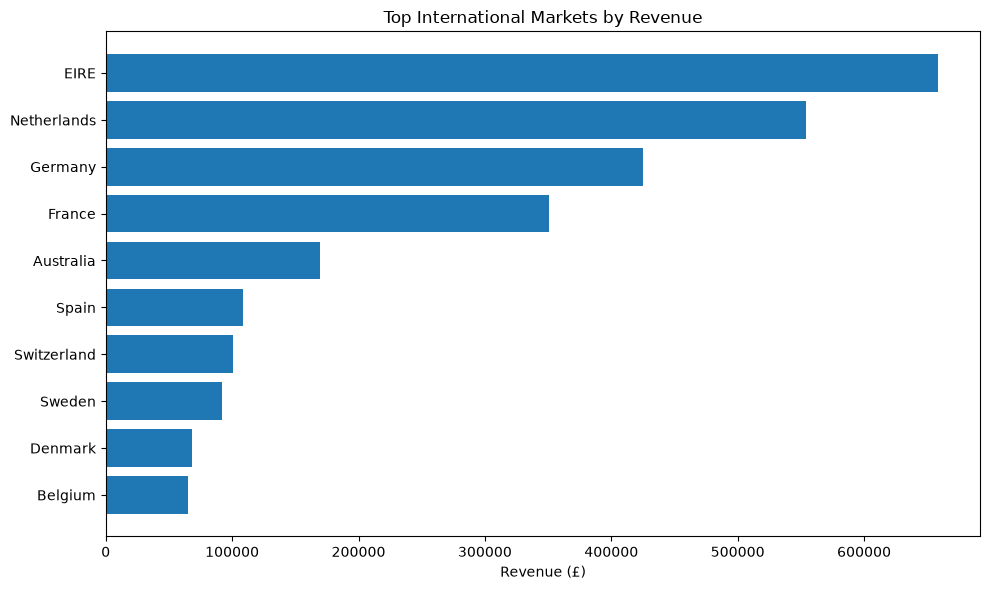

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    international_revenue["Country"][::-1],
    international_revenue["Revenue"][::-1]
)

plt.title("Top International Markets by Revenue")
plt.xlabel("Revenue (£)")

plt.tight_layout()
plt.show()

## PRODUCTS

Which products actually drive sales?

In [32]:
product_analysis = (
    sales_df
    .groupby(
        ["StockCode", "Description"],
        as_index=False
    )
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

product_analysis.head(20)

,StockCode,Description,Revenue,UnitsSold,Orders
5615,M,Manual,"339,226.24",9629,784
1757,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918
5614,DOT,DOTCOM POSTAGE,"309,854.11",1415,1415
5157,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356
3221,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
3372,47566,PARTY BUNTING,"148,318.28",28200,2674
5139,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245
3716,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807
5617,POST,POSTAGE,"125,682.42",5363,1851
1343,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018


In [33]:
#remove non-product items
excluded_descriptions = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "Manual",
    "CARRIAGE"
]

real_products = product_analysis[
    ~product_analysis["Description"].isin(
        excluded_descriptions
    )
].copy()

top_products = real_products.head(10)

top_products

,StockCode,Description,Revenue,UnitsSold,Orders
1757,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918
5157,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356
3221,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
3372,47566,PARTY BUNTING,"148,318.28",28200,2674
5139,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245
3716,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807
1343,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018
2676,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247
3495,79321,CHILLI LIGHTS,"80,540.88",15841,1135
3561,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"71,300.40",31409,756


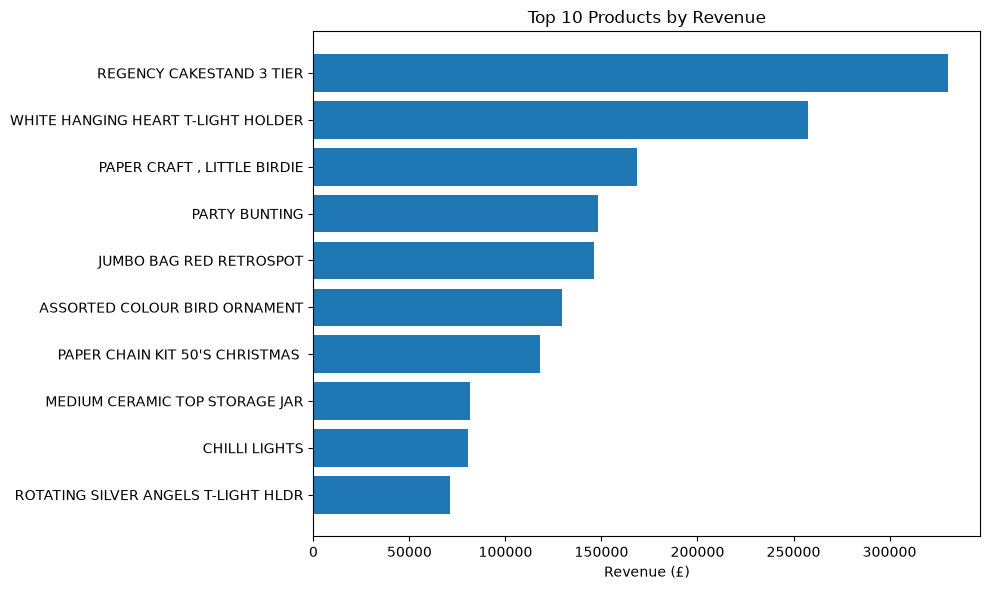

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"][::-1],
    top_products["Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")

plt.tight_layout()
plt.show()

## CUSTOMER ANALYSIS

Is revenue broadly distributed across customers, or concentrated among a small number of high-value buyers?

In [35]:
customer_sales = sales_df[
    sales_df["CustomerID"].notna()
].copy()

In [36]:
customer_summary = (
    customer_sales
    .groupby("CustomerID", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        UnitsPurchased=("Quantity", "sum"),
        LastPurchase=("InvoiceDate", "max")
    )
)

customer_summary["AverageOrderValue"] = (
    customer_summary["Revenue"] /
    customer_summary["Orders"]
)

customer_summary = customer_summary.sort_values(
    "Revenue",
    ascending=False
)

customer_summary.head(10)

,CustomerID,Revenue,Orders,UnitsPurchased,LastPurchase,AverageOrderValue
5692,"18,102.00","580,987.04",145,181645,2011-12-09 11:50:00,"4,006.81"
2277,"14,646.00","528,602.52",151,367193,2011-12-08 12:12:00,"3,500.68"
1789,"14,156.00","313,437.62",156,164325,2011-11-30 10:54:00,"2,009.22"
2538,"14,911.00","291,420.81",398,147972,2011-12-08 15:54:00,732.21
5050,"17,450.00","244,784.25",51,83914,2011-12-01 13:29:00,"4,799.69"
1331,"13,694.00","195,640.69",143,188201,2011-12-06 09:32:00,"1,368.12"
5109,"17,511.00","172,132.87",60,117174,2011-12-07 10:12:00,"2,868.88"
4061,"16,446.00","168,472.50",2,80997,2011-12-09 09:15:00,"84,236.25"
4295,"16,684.00","147,142.77",55,104810,2011-12-05 14:06:00,"2,675.32"
68,"12,415.00","144,458.37",28,91447,2011-11-15 14:22:00,"5,159.23"


### PARETO ANALYSIS

What percentage of revenue is generated by the top 20% of customers?

In [37]:
customer_summary = customer_summary.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

top_20_count = int(
    len(customer_summary) * 0.20
)

top_20_revenue = (
    customer_summary
    .iloc[:top_20_count]["Revenue"]
    .sum()
)

customer_revenue_share = (
    top_20_revenue /
    customer_summary["Revenue"].sum() *
    100
)

print(
    f"Top 20% of customers generate "
    f"{customer_revenue_share:.1f}% of customer revenue."
)

Top 20% of customers generate 77.2% of customer revenue.


## RFM ANALYSIS

In [38]:
reference_date = (
    customer_sales["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

reference_date

Timestamp('2011-12-10 12:50:00')

In [39]:
rfm = (
    customer_sales
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=(
            "InvoiceNo",
            "nunique"
        ),
        Monetary=(
            "Revenue",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,"12,346.00",326,12,"77,556.46"
1,"12,347.00",2,8,"4,921.53"
2,"12,348.00",75,5,"2,019.40"
3,"12,349.00",19,4,"4,428.69"
4,"12,350.00",310,1,334.40


In [ ]:
#RFM SCORES (less = better)
rfm["R"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4, 3, 2, 1]
)

In [41]:
#more = better
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["M"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1, 2, 3, 4]
)

In [42]:
rfm["R"] = rfm["R"].astype(int)
rfm["F"] = rfm["F"].astype(int)
rfm["M"] = rfm["M"].astype(int)

rfm["RFMScore"] = (
    rfm["R"] +
    rfm["F"] +
    rfm["M"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFMScore
0,"12,346.00",326,12,"77,556.46",2,4,4,10
1,"12,347.00",2,8,"4,921.53",4,4,4,12
2,"12,348.00",75,5,"2,019.40",3,3,3,9
3,"12,349.00",19,4,"4,428.69",4,3,4,11
4,"12,350.00",310,1,334.40,2,1,1,4


In [43]:
def customer_segment(row):

    if (
        row["R"] >= 3 and
        row["F"] >= 3 and
        row["M"] >= 3
    ):
        return "Champions"

    elif (
        row["F"] >= 3 and
        row["M"] >= 3
    ):
        return "Loyal Customers"

    elif (
        row["R"] >= 3 and
        row["F"] <= 2
    ):
        return "Potential Loyalists"

    elif (
        row["R"] <= 2 and
        row["F"] >= 3
    ):
        return "At Risk"

    else:
        return "Other"

In [44]:
rfm["Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

rfm["Segment"].value_counts()

Segment
Other                  2283
Champions              1821
Potential Loyalists     894
Loyal Customers         643
At Risk                 237
Name: count, dtype: int64

## VALUE OF SEGMENTS

In [45]:
segment_analysis = (
    rfm
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        Revenue=("Monetary", "sum"),
        AvgRevenue=("Monetary", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRecency=("Recency", "mean")
    )
)

segment_analysis["RevenueShare"] = (
    segment_analysis["Revenue"] /
    segment_analysis["Revenue"].sum() *
    100
)

segment_analysis = segment_analysis.sort_values(
    "Revenue",
    ascending=False
)

segment_analysis

,Segment,Customers,Revenue,AvgRevenue,AvgFrequency,AvgRecency,RevenueShare
1,Champions,1821,"13,186,331.03","7,241.26",14.07,29.30,75.89
2,Loyal Customers,643,"2,025,600.27","3,150.23",7.37,267.43,11.66
3,Other,2283,"1,259,998.18",551.90,1.76,372.23,7.25
4,Potential Loyalists,894,"763,447.52",853.97,1.78,40.72,4.39
0,At Risk,237,"139,427.27",588.30,4.23,303.43,0.80


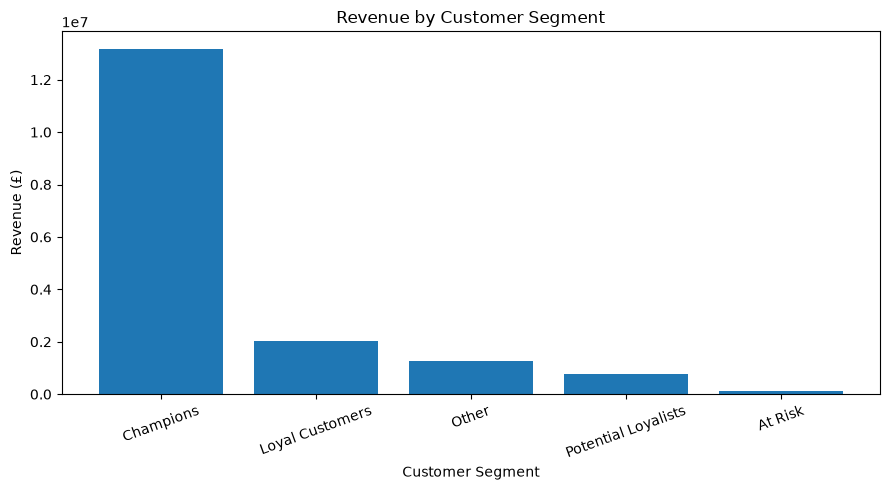

In [46]:
plt.figure(figsize=(9, 5))

plt.bar(
    segment_analysis["Segment"],
    segment_analysis["Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [47]:
# saving cleaned data
sales_df.to_csv(
    "../data/processed/clean_transactions.csv",
    index=False
)

rfm.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)

In [48]:
#PREPARE EXCEL DATA
with pd.ExcelWriter(
    "../data/processed/excel_dashboard_data.xlsx",
    engine="openpyxl"
) as writer:

    monthly_revenue.to_excel(
        writer,
        sheet_name="Monthly Revenue",
        index=False
    )

    country_revenue.to_excel(
        writer,
        sheet_name="Countries",
        index=False
    )

    real_products.to_excel(
        writer,
        sheet_name="Products",
        index=False
    )

    customer_summary.to_excel(
        writer,
        sheet_name="Customers",
        index=False
    )

    rfm.to_excel(
        writer,
        sheet_name="RFM",
        index=False
    )

    segment_analysis.to_excel(
        writer,
        sheet_name="Segments",
        index=False
    )

In [49]:
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Customers: {total_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")
print(f"UK Revenue Share: {uk_share:.1f}%")
print(f"Top 20% Customer Revenue: {customer_revenue_share:.1f}%")

Total Revenue: £20,476,260.45
Total Orders: 40,077
Customers: 5,878
Average Order Value: £510.92
UK Revenue Share: 85.0%
Top 20% Customer Revenue: 77.2%


In [50]:
kpi_table = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Orders",
        "Customers",
        "AOV",
        "UK Revenue Share",
        "Top 20% Customer Revenue"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value,
        uk_share / 100,
        customer_revenue_share / 100
    ]
})

kpi_table

,KPI,Value
0,Total Revenue,"20,476,260.45"
1,Orders,"40,077.00"
2,Customers,"5,878.00"
3,AOV,510.92
4,UK Revenue Share,0.85
5,Top 20% Customer Revenue,0.77
